TypeError: unsupported operand type(s) for @: 'numpy.ndarray' and 'Qobj'

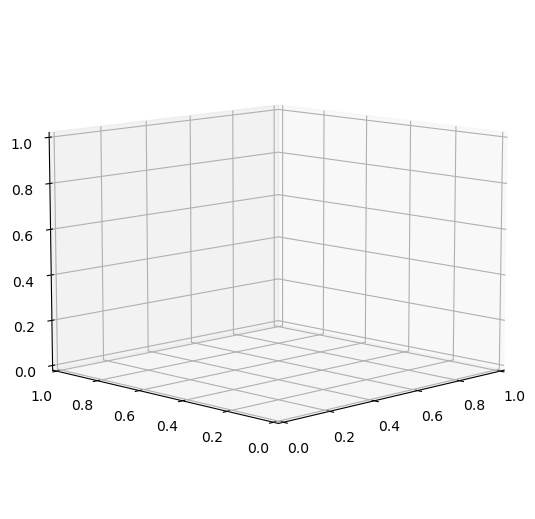

In [2]:
from qutip import qpt, Qobj, Bloch, sigmax, sigmay, sigmaz
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_fidelity_on_bloch(rho1, rho2):
    # Create bloch sphere
    fig = plt.figure(figsize=(5, 5))
    ax = Axes3D(fig, auto_add_to_figure=False, azim=-135, elev=10)
    fig.add_axes(ax)
    sphere = Bloch(axes=ax)

    # Add rho1 and rho2 vectors to bloch sphere
    sphere.add_vectors([[np.real(np.trace(Qobj(rho).full() @ sigmax())),
                     np.real(np.trace(Qobj(rho).full() @ sigmay())),
                     np.real(np.trace(Qobj(rho).full() @ sigmaz()))]
                    for rho in [Qobj(rho1), Qobj(rho2)]])
    
    # Set limits for bloch sphere plot
    sphere.vector_color = ['red', 'blue']
    sphere.vector_width = 3.0
    sphere.font_size = 12
    sphere.make_sphere()

    # Plot the fidelity between rho1 and rho2
    fidelity = np.real(qpt(Qobj(rho1), Qobj(rho2))['fidelity'])
    ax.text2D(0.05, 0.95, f'Fidelity: {fidelity:.2f}', transform=ax.transAxes)

    plt.show()

# Define two density matrices to compare
rho1 = np.array([[1, 0], [0, 0]])
rho2 = np.array([[1/2, 1/2], [1/2, 1/2]])

# Plot fidelity on bloch sphere
plot_fidelity_on_bloch(rho1, rho2)